# Rough Heston QIPC Demo

This notebook demonstrates the main features of `rough-heston-qipc`: single option pricing, call and put pricing, parameter-grid pricing, numerical-grid pricing, and comparison between the implicit and explicit fractional Adams solvers across different option moneyness regimes.

In [121]:
# Install the published package when running in Colab.
# If you run this notebook from a local editable checkout, you can skip this cell.
!pip install rough-heston-qipc --quiet

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rough_heston_qipc import RoughHestonModel, RoughHestonParams

## 1. Model setup

`RoughHestonParams` has no default values, so every model and numerical parameter is explicit. This makes experiments reproducible and avoids hidden assumptions.

In [123]:
base_params = RoughHestonParams(
    S0=100.0,
    K=100.0,
    r=0.0,
    z=0.4,
    alpha=0.6,
    lam=2.0,
    theta=0.04,
    rho=-0.5,
    nu=0.05,
    t=1.0,
    R=1.5,
    u_lower=0.0,
    u_upper=25.0,
)

model = RoughHestonModel(base_params)
base_params

RoughHestonParams(S0=100.0, K=100.0, r=0.0, z=0.4, alpha=0.6, lam=2.0, theta=0.04, rho=-0.5, nu=0.05, t=1.0, R=1.5, u_lower=0.0, u_upper=25.0)

## 2. Single call and put prices

`price` computes a single value when all parameters are scalars. The `option_type` argument selects call or put, and `timed=True` returns the elapsed computation time.

In [124]:
call_price, call_time = model.price(
    NOuter=50,
    NInner=500,
    method="implicit",
    option_type="call",
    timed=True,
)

put_price, put_time = model.price(
    NOuter=50,
    NInner=500,
    method="implicit",
    option_type="put",
    timed=True,
)

pd.DataFrame(
    [
        {"option_type": "call", "price": call_price, "elapsed": call_time},
        {"option_type": "put", "price": put_price, "elapsed": put_time},
    ]
)

,option_type,price,elapsed
0,call,16.690061,0.045739
1,put,16.690061,0.034061


## 3. Parameter-grid pricing

If any `RoughHestonParams` field is a list, `price` automatically prices every combination of list-valued parameters. Each returned row contains only the varied parameters, plus the price and optional elapsed time.

In [125]:
strike_maturity_params = RoughHestonParams(
    S0=100.0,
    K=[80.0, 90.0, 100.0, 110.0, 120.0],
    r=0.0,
    z=0.4,
    alpha=0.6,
    lam=2.0,
    theta=0.04,
    rho=-0.5,
    nu=0.05,
    t=[0.5, 1.0],
    R=1.5,
    u_lower=0.0,
    u_upper=25.0,
)

grid_model = RoughHestonModel(strike_maturity_params)
param_grid_rows = grid_model.price(NOuter=35, NInner=200, timed=True)
param_grid_df = pd.DataFrame(param_grid_rows)
param_grid_df

,K,t,price,elapsed
0,80.0,0.5,24.458175,0.003871
1,80.0,1.0,27.166841,0.003606
2,90.0,0.5,18.116550,0.003691
3,90.0,1.0,21.411928,0.003605
4,100.0,0.5,13.070468,0.003676
5,100.0,1.0,16.689489,0.003705
6,110.0,0.5,9.214982,0.003752
7,110.0,1.0,12.891622,0.003556
8,120.0,0.5,6.369497,0.003473
9,120.0,1.0,9.886430,0.003676


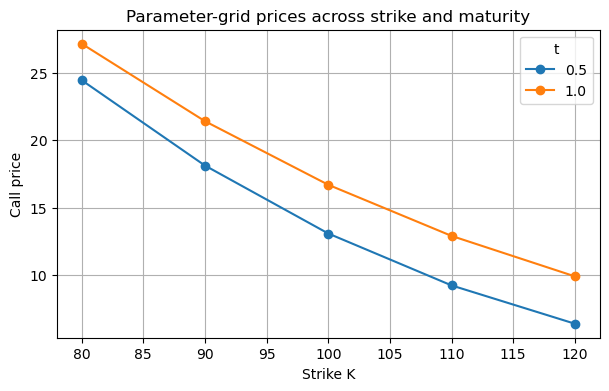

In [126]:
pivot_prices = param_grid_df.pivot(index="K", columns="t", values="price")

ax = pivot_prices.plot(marker="o", figsize=(7, 4))
ax.set_xlabel("Strike K")
ax.set_ylabel("Call price")
ax.set_title("Parameter-grid prices across strike and maturity")
ax.grid(True)
plt.show()

## 4. Numerical-grid pricing with `price_grid`

`price_grid` is for numerical experiments over `NOuter` and `NInner`. It requires scalar model parameters and returns a DataFrame with `NInner` as rows and `NOuter` as columns. With `timed=True`, it returns a price DataFrame and an elapsed-time DataFrame.

In [127]:
n_outer_values = [20, 35, 50]
n_inner_values = [100, 200, 400]

implicit_price_df, implicit_time_df = model.price_grid(
    NOuter_values=n_outer_values,
    NInner_values=n_inner_values,
    method="implicit",
    option_type="call",
    timed=True,
)

implicit_price_df

NOuter,20,35,50
NInner,,,
100,16.638905,16.688345,16.688472
200,16.640048,16.689489,16.689616
400,16.640435,16.689875,16.690003


In [128]:
implicit_time_df

NOuter,20,35,50
NInner,,,
100,0.001889,0.001935,0.002129
200,0.003206,0.003507,0.003840
400,0.006350,0.016498,0.031104


## 5. Reference prices from both methods

Before comparing speed, first compute high-resolution reference prices from both methods. The references should be very close; otherwise a speed comparison at a fixed error tolerance would not be meaningful.

In [129]:
reference_grid = (1000, 2000)
reference_agreement_tol = 1e-4

contract_specs = [
    {"label": "ITM call", "K": 80.0, "option_type": "call"},
    {"label": "ATM call", "K": 100.0, "option_type": "call"},
    {"label": "OTM call", "K": 120.0, "option_type": "call"},
    {"label": "OTM put", "K": 80.0, "option_type": "put"},
    {"label": "ATM put", "K": 100.0, "option_type": "put"},
    {"label": "ITM put", "K": 120.0, "option_type": "put"},
]

def params_with_strike(strike):
    return RoughHestonParams(
        S0=base_params.S0,
        K=strike,
        r=base_params.r,
        z=base_params.z,
        alpha=base_params.alpha,
        lam=base_params.lam,
        theta=base_params.theta,
        rho=base_params.rho,
        nu=base_params.nu,
        t=base_params.t,
        R=base_params.R,
        u_lower=base_params.u_lower,
        u_upper=base_params.u_upper,
    )

reference_rows = []
for spec in contract_specs:
    contract_model = RoughHestonModel(params_with_strike(spec["K"]))
    implicit_reference, implicit_reference_time = contract_model.price(
        *reference_grid,
        method="implicit",
        option_type=spec["option_type"],
        timed=True,
    )
    explicit_reference, explicit_reference_time = contract_model.price(
        *reference_grid,
        method="explicit",
        option_type=spec["option_type"],
        timed=True,
    )
    reference_rows.append(
        {
            **spec,
            "implicit_reference": implicit_reference,
            "explicit_reference": explicit_reference,
            "reference_price": 0.5 * (implicit_reference + explicit_reference),
            "reference_gap": abs(implicit_reference - explicit_reference),
            "implicit_reference_time": implicit_reference_time,
            "explicit_reference_time": explicit_reference_time,
            "reference_match": abs(implicit_reference - explicit_reference) < reference_agreement_tol,
        }
    )

reference_df = pd.DataFrame(reference_rows)
reference_df

,label,K,option_type,implicit_reference,explicit_reference,reference_price,reference_gap,implicit_reference_time,explicit_reference_time,reference_match
0,ITM call,80.0,call,27.167376,27.167401,27.167388,0.000025,0.868346,0.767716,True
1,ATM call,100.0,call,16.690182,16.690217,16.690200,0.000035,0.915721,0.848320,True
2,OTM call,120.0,call,9.887160,9.887197,9.887178,0.000037,0.873510,0.794453,True
3,OTM put,80.0,put,7.167376,7.167401,7.167388,0.000025,0.886242,0.809706,True
4,ATM put,100.0,put,16.690182,16.690217,16.690200,0.000035,0.807977,0.692725,True
5,ITM put,120.0,put,29.887160,29.887197,29.887178,0.000037,0.843659,0.780221,True


In [130]:
if not reference_df["reference_match"].all():
    raise RuntimeError("Implicit and explicit references are not close enough. Increase reference_grid or relax reference_agreement_tol.")

print(f"All reference gaps are below {reference_agreement_tol:g}.")

All reference gaps are below 0.0001.


## 6.Accuracy–Runtime Comparison

We evaluates the computational efficiency of the **implicit** and **explicit** pricing methods under controlled accuracy requirements. 

In [131]:
candidate_outer_values = [25, 50, 100]
candidate_inner_values = [50, 100, 150, 200, 300, 400, 600, 800]

accuracy_tolerances = [1e-2, 5e-3, 1e-3, 5e-4]

strike_values = np.arange(80, 121, 5)
option_type = "call"

methods = ["implicit", "explicit"]

In [132]:
def compute_reference_prices_by_method(K, option_type):
    reference_params = params_with_strike(K)
    reference_model = RoughHestonModel(reference_params)

    reference_prices = {}

    for method in methods:
        reference_prices[method] = reference_model.price(
            NOuter=1000,
            NInner=2000,
            method=method,
            option_type=option_type,
            timed=False,
        )

    return reference_prices

In [133]:
def grid_accuracy_runs(params, option_type, reference_prices, outer_values, inner_values):
    rows = []
    contract_model = RoughHestonModel(params)

    for method in methods:
        method_reference_price = reference_prices[method]

        for n_outer in outer_values:
            for n_inner in inner_values:
                price, elapsed = contract_model.price(
                    NOuter=n_outer,
                    NInner=n_inner,
                    method=method,
                    option_type=option_type,
                    timed=True,
                )

                rows.append(
                    {
                        "method": method,
                        "NOuter": n_outer,
                        "NInner": n_inner,
                        "price": price,
                        "reference_price": method_reference_price,
                        "error": abs(price - method_reference_price),
                        "elapsed": elapsed,
                    }
                )

    return pd.DataFrame(rows)

In [134]:
def fastest_time_under_tolerance(runs_df, tolerance):
    rows = []

    for method, method_df in runs_df.groupby("method"):
        eligible = method_df[method_df["error"] <= tolerance]

        if eligible.empty:
            rows.append(
                {
                    "method": method,
                    "tolerance": tolerance,
                    "best_elapsed": np.nan,
                    "NOuter": np.nan,
                    "NInner": np.nan,
                    "error": np.nan,
                    "price": np.nan,
                    "reference_price": np.nan,
                }
            )
            continue

        best = eligible.loc[eligible["elapsed"].idxmin()]

        rows.append(
            {
                "method": method,
                "tolerance": tolerance,
                "best_elapsed": best["elapsed"],
                "NOuter": int(best["NOuter"]),
                "NInner": int(best["NInner"]),
                "error": best["error"],
                "price": best["price"],
                "reference_price": best["reference_price"],
            }
        )

    return pd.DataFrame(rows)

In [135]:
all_runs = []
all_best_times = []

for K in strike_values:
    reference_prices = compute_reference_prices_by_method(K, option_type)

    runs_df = grid_accuracy_runs(
        params=params_with_strike(K),
        option_type=option_type,
        reference_prices=reference_prices,
        outer_values=candidate_outer_values,
        inner_values=candidate_inner_values,
    ).assign(
        K=K,
        option_type=option_type,
        reference_price_implicit=reference_prices["implicit"],
        reference_price_explicit=reference_prices["explicit"],
    )

    all_runs.append(runs_df)

    for tolerance in accuracy_tolerances:
        best_time_df = fastest_time_under_tolerance(
            runs_df,
            tolerance,
        ).assign(
            K=K,
            option_type=option_type,
            reference_price_implicit=reference_prices["implicit"],
            reference_price_explicit=reference_prices["explicit"],
        )

        all_best_times.append(best_time_df)

all_runs_df = pd.concat(all_runs, ignore_index=True)
all_best_time_df = pd.concat(all_best_times, ignore_index=True)

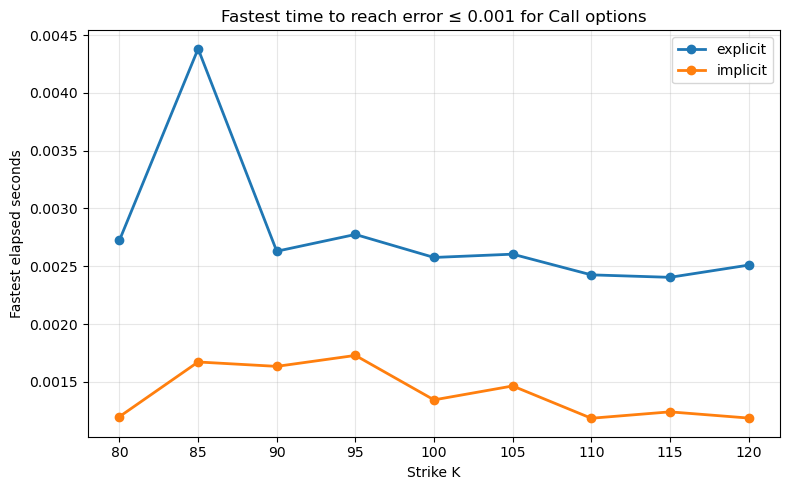

In [136]:
def plot_time_vs_strike(best_time_df, option_type, tolerance):
    plot_df = best_time_df[
        (best_time_df["option_type"] == option_type)
        & (best_time_df["tolerance"] == tolerance)
    ].copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    for method, group in plot_df.groupby("method"):
        group = group.sort_values("K")

        ax.plot(
            group["K"],
            group["best_elapsed"],
            marker="o",
            linewidth=2,
            label=method,
        )

    ax.set_xlabel("Strike K")
    ax.set_ylabel("Fastest elapsed seconds")
    ax.set_title(
        f"Fastest time to reach error ≤ {tolerance:g} "
        f"for {option_type.capitalize()} options"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_time_vs_strike(
    all_best_time_df,
    option_type=option_type,
    tolerance=1e-3,
)

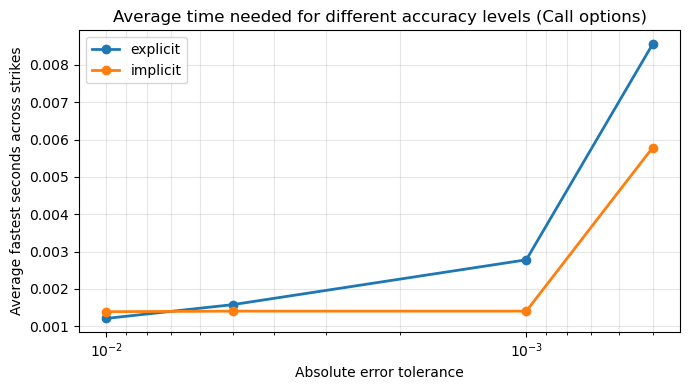

In [137]:
def plot_average_time_vs_tolerance(best_time_df, option_type):
    tolerance_plot_df = (
        best_time_df
        .dropna(subset=["best_elapsed"])
        .groupby(["tolerance", "method"], as_index=False)["best_elapsed"]
        .mean()
    )

    tolerance_plot_df = tolerance_plot_df.sort_values(["method", "tolerance"])

    fig, ax = plt.subplots(figsize=(7, 4))

    for method, group in tolerance_plot_df.groupby("method"):
        group = group.sort_values("tolerance")

        ax.plot(
            group["tolerance"],
            group["best_elapsed"],
            marker="o",
            linewidth=2,
            label=method,
        )

    ax.set_xscale("log")
    ax.invert_xaxis()

    ax.set_xlabel("Absolute error tolerance")
    ax.set_ylabel("Average fastest seconds across strikes")
    ax.set_title(
        f"Average time needed for different accuracy levels "
        f"({option_type.capitalize()} options)"
    )

    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_average_time_vs_tolerance(
    all_best_time_df,
    option_type=option_type,
)